# Text Processing Fundamentals and OCR

This notebook introduces the fundamentals of **Optical Character Recognition (OCR)** and **text preprocessing** in the context of Information Extraction (IE).

In many real-world IE scenarios, documents are not available as clean text. Instead, they appear as scanned PDFs, photos, receipts, invoices, or forms. Before we can extract structured information from them, we first need to convert them into machine-readable text.

This notebook combines conceptual explanations with hands-on examples using **EasyOCR**, **regular expressions**, and **spaCy**.

**Learning Objectives:**
By the end of this notebook, you should be able to:
- Explain conceptually how OCR works.
- Understand common OCR errors and why preprocessing is necessary.
- Run OCR on document images using EasyOCR.
- Build a basic text preprocessing pipeline for OCR output.
- Reflect on the limitations of OCR and rule-based cleaning.

---

## 1. Optical Character Recognition (OCR)

### What is OCR?
**Optical Character Recognition (OCR)** is the process of converting text contained in images into machine-readable text.

OCR is a foundational technology for many Information Extraction pipelines because documents such as scanned invoices, receipts, forms, and reports are often stored as **images or PDFs**, not as clean text files.

In other words:
- **Input:** image or scanned document
- **Output:** text

### Why OCR matters for IE
In the previous session, we worked with clean text directly. In practice, however, we often need to extract information from:
- scanned invoices
- photographed receipts
- medical documents
- administrative forms

Before any extraction step can happen, we need to recover the text first.

### OCR Pipeline (conceptually)
A simplified OCR pipeline typically consists of the following steps:
1. **Text Detection** – find regions in the image that contain text
2. **Segmentation** – divide text into lines, words, or characters
3. **Recognition** – predict which characters or words are present
4. **Post-processing** – improve the output using heuristics or language knowledge

### Why OCR is difficult
OCR is rarely perfect. Errors may occur because of:
- low image quality
- unusual fonts
- skewed or rotated text
- complex layouts
- tables and multi-column documents
- visually similar characters such as `O` and `0`, or `I` and `1`

---

### Hands-On: Running OCR with EasyOCR

In this section, we use the `EasyOCR` library to run OCR on a sample document image and inspect its output.

In [52]:
import re
from pathlib import Path

import easyocr
import spacy
from rich import print as rprint

In [53]:
# Initialize EasyOCR reader
# Set gpu=True if you have GPU support available.
reader = easyocr.Reader(['en'], gpu=False)

Using CPU. Note: This module is much faster with a GPU.


Loaded: True
Shape: (1000, 771, 3)


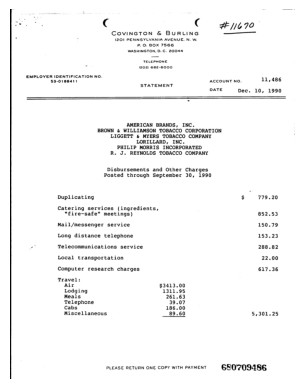

In [73]:
import cv2
import easyocr
import matplotlib.pyplot as plt

image_path = "../../data/0013046347.tif"

img = cv2.imread(image_path)
print("Loaded:", img is not None)
print("Shape:", img.shape)

# BGR -> RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [74]:
reader = easyocr.Reader(['en'], gpu=False)
results = reader.readtext(img_rgb)
results[:3]

Using CPU. Note: This module is much faster with a GPU.


[([[564, 32], [664, 32], [664, 60], [564, 60]], '#/1670', 0.7938645410936976),
 ([[272, 59], [386, 59], [386, 75], [272, 75]],
  'CovinGtoN',
  0.5904527405768863),
 ([[421, 57], [513, 57], [513, 75], [421, 75]], 'BURLING', 0.8411021511863915)]

In [75]:
results[3:10]

[([[283, 77], [473, 77], [473, 91], [283, 91]],
  'i20i PENNSYLVANIA AVENUE',
  0.5025283250636902),
 ([[375, 91], [445, 91], [445, 105], [375, 105]],
  'box 7566',
  0.4017623987619946),
 ([[317, 107], [395, 107], [395, 121], [317, 121]],
  'WaShinGTON_',
  0.47437643817653996),
 ([[429, 107], [471, 107], [471, 121], [429, 121]],
  '20044',
  0.9996305396793211),
 ([[360, 138], [426, 138], [426, 146], [360, 146]],
  'TELEPHOHC',
  0.5210221588332865),
 ([[350, 154], [374, 154], [374, 162], [350, 162]],
  'R0z',
  0.12039358931481736),
 ([[380, 154], [402, 154], [402, 162], [380, 162]], '662', 0.9623411805895341)]

EasyOCR returns a list of predictions. Each prediction typically contains:
- a **bounding box**
- the **recognized text**
- a **confidence score**

This is useful because OCR does not only produce text — it also provides weak layout information through coordinates.

In [76]:
print(f"{'Detected Text':<35} {'Confidence'}")
print('-' * 55)

for item in results:
    bbox, text, conf = item
    print(f"{text:<35} {conf:.4f}")

Detected Text                       Confidence
-------------------------------------------------------
#/1670                              0.7939
CovinGtoN                           0.5905
BURLING                             0.8411
i20i PENNSYLVANIA AVENUE            0.5025
box 7566                            0.4018
WaShinGTON_                         0.4744
20044                               0.9996
TELEPHOHC                           0.5210
R0z                                 0.1204
662                                 0.9623
000                                 0.3774
EMPLOYER IDENTIFICATION No_         0.8523
53-018041 1                         0.7886
ACCOUNT No                          0.5251
486                                 1.0000
STATEMENT                           0.9810
DATE                                0.9990
Dec                                 1.0000
10                                  0.9990
1990                                0.9974
AMERICAN                            0

### From OCR Output to Raw Text

In many simple pipelines, we concatenate all OCR predictions into one text string. This is often the starting point for preprocessing and downstream extraction.

In [58]:
raw_text = ' '.join([item[1] for item in results])
print(raw_text)

REWE Rewe Thomas Lutz_oHG Blumenstr 7/B27 72144 DuB | ingen Steuernr 32018714852 Tel '07072-6009502 UID Nr _ 'DE286339160 EUR 2,98 B LEERDAMMER ORIG 2 Stk X 1,49 PATROS"  SCHAF-FEI KARTOFFELAUFLAUFE SEuEesscheLT#SCh H VEG BRATWUR; VEGANE   SALAMI GURKE BIO 1 KINDER PARADISO 1 BEDRTEFRAN RIEGEL 1, | GASZHOKANDEL L VEFAEXNFEUTEMANI L PFAND 0,25 EURO X COLOR DISCS SUHME EUR 40,38 Geg: BAR EUR 40,38 Stever 5 Netto Steuer Brutto A= 19,0% 7,50 1,43 8,93 B= 7,0% 29,39 2,06 31,45 Gesamtbetrag 36, 89 3,49 40,38 TSE-Signatur ; QObTWdIota]PPD00O9s9SC+EAL / fGNLxz hJZCwKr hdhkotjfQAzXhIXhteAz#ROMTd 4YozvitnjiuuOMFu7WGdTsfw3k?IKaxoh ZiqKksbOVntOFs7IE9O4yLav+C24Gx TSE-Signaturzuhler : 1860736 TSE-Transaktion: 876364 TSE-Start: 2024-10-02T16:21:52.000 TSE-Stop: 2024-10-02T16:22:57.000 Ser iennnummer Kasse: REWE:b4:2e:99:de:96:ab:00 02. 10.2024 16:22 Bon-Nr Markt:5671 Kasse: 2 Bed, : 181818 XkrkkkkarxkKxxxxkarrrkkxxxbekkkkorakkkxk Noch keine PAYBACK Du Fur  diesen Einkauf hattest 20, Punkte erhaIteni 

## 2. OCR Errors and the Need for Preprocessing

The raw OCR output is often noisy and difficult to use directly for downstream tasks.

Typical issues include:
- inconsistent casing
- broken whitespace
- missing punctuation
- character confusions (`0` vs `O`, `1` vs `I`)
- merged or split tokens
- layout-dependent ordering problems

This is why **text preprocessing** is an essential intermediate step between OCR and extraction.

In [59]:
example_noisy_text = 'Inv0ice   #I234   t0tal : €45O   Date 12.O5.2024'
print(example_noisy_text)

Inv0ice   #I234   t0tal : €45O   Date 12.O5.2024


### What is Text Preprocessing?

Text preprocessing refers to the transformation of raw text into a more normalized and usable form.

Depending on the application, preprocessing may include:
- lowercasing
- removing noise characters
- normalizing whitespace
- standardizing dates or currency formats
- tokenization
- linguistic annotation

The goal is not to make the text perfect, but to make it **more robust for downstream analysis**.

In [60]:
def clean_text(text: str) -> str:
    """Basic preprocessing for OCR output."""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)              # normalize whitespace
    text = re.sub(r"[|_~]", " ", text)            # remove common OCR artefacts
    text = re.sub(r"\s+([:,.€])", r"\1", text)   # remove spaces before punctuation
    return text.strip()

In [61]:
cleaned_text = clean_text(raw_text)

print('RAW TEXT:')
print(raw_text)
print('\n' + '-' * 60 + '\n')
print('CLEANED TEXT:')
print(cleaned_text)

RAW TEXT:
REWE Rewe Thomas Lutz_oHG Blumenstr 7/B27 72144 DuB | ingen Steuernr 32018714852 Tel '07072-6009502 UID Nr _ 'DE286339160 EUR 2,98 B LEERDAMMER ORIG 2 Stk X 1,49 PATROS"  SCHAF-FEI KARTOFFELAUFLAUFE SEuEesscheLT#SCh H VEG BRATWUR; VEGANE   SALAMI GURKE BIO 1 KINDER PARADISO 1 BEDRTEFRAN RIEGEL 1, | GASZHOKANDEL L VEFAEXNFEUTEMANI L PFAND 0,25 EURO X COLOR DISCS SUHME EUR 40,38 Geg: BAR EUR 40,38 Stever 5 Netto Steuer Brutto A= 19,0% 7,50 1,43 8,93 B= 7,0% 29,39 2,06 31,45 Gesamtbetrag 36, 89 3,49 40,38 TSE-Signatur ; QObTWdIota]PPD00O9s9SC+EAL / fGNLxz hJZCwKr hdhkotjfQAzXhIXhteAz#ROMTd 4YozvitnjiuuOMFu7WGdTsfw3k?IKaxoh ZiqKksbOVntOFs7IE9O4yLav+C24Gx TSE-Signaturzuhler : 1860736 TSE-Transaktion: 876364 TSE-Start: 2024-10-02T16:21:52.000 TSE-Stop: 2024-10-02T16:22:57.000 Ser iennnummer Kasse: REWE:b4:2e:99:de:96:ab:00 02. 10.2024 16:22 Bon-Nr Markt:5671 Kasse: 2 Bed, : 181818 XkrkkkkarxkKxxxxkarrrkkxxxbekkkkorakkkxk Noch keine PAYBACK Du Fur  diesen Einkauf hattest 20, Punkte 

### Important Note

Preprocessing improves usability, but it does not solve all OCR problems.

For example:
- if the OCR model reads `€450` as `€45O`, cleaning alone may not always recover the correct value
- if the reading order is wrong due to layout issues, a plain text cleaning step may not be enough

This highlights an important principle in IE:

> Preprocessing helps reduce noise, but it cannot fully replace better document models or stronger extraction methods.

## 3. Linguistic Processing with spaCy

After cleaning OCR output, we can treat it as text and process it with NLP libraries such as **spaCy**.

This allows us to:
- tokenize the text
- inspect sentence boundaries
- assign part-of-speech tags
- prepare the text for downstream extraction tasks

In [62]:
nlp = spacy.load('en_core_web_sm')
doc = nlp(cleaned_text)

In [63]:
print(f"{'Token':<20} {'POS':<10} {'is_alpha':<10}")
print('-' * 45)

for token in doc[:25]:
    print(f"{token.text:<20} {token.pos_:<10} {str(token.is_alpha):<10}")

Token                POS        is_alpha  
---------------------------------------------
rewe                 PROPN      True      
rewe                 PROPN      True      
thomas               PROPN      True      
lutz                 PROPN      True      
ohg                  PROPN      True      
blumenstr            PROPN      True      
7                    NUM        False     
/                    SYM        False     
b27                  NOUN       False     
72144                NUM        False     
dub                  VERB       True      
                     SPACE      False     
ingen                PROPN      True      
steuernr             PROPN      True      
32018714852          NUM        False     
tel                  NOUN       True      
'                    NUM        False     
07072                NUM        False     
-                    SYM        False     
6009502              NUM        False     
uid                  ADJ        True      
nr      

### Document Representation

Once OCR text has been extracted and cleaned, we need to decide how to represent it for downstream processing.

Common representations include:
- **Plain text**: useful for simple pipelines
- **Tokens**: useful for NLP models and linguistic analysis
- **Structured chunks**: useful when documents have fields, sections, or layouts

The representation we choose affects what kinds of extraction methods will work well later.

In [64]:
tokens = [token.text for token in doc]
tokens[:30]

['rewe',
 'rewe',
 'thomas',
 'lutz',
 'ohg',
 'blumenstr',
 '7',
 '/',
 'b27',
 '72144',
 'dub',
 '  ',
 'ingen',
 'steuernr',
 '32018714852',
 'tel',
 "'",
 '07072',
 '-',
 '6009502',
 'uid',
 'nr',
 '  ',
 "'",
 'de286339160',
 'eur',
 '2,98',
 'b',
 'leerdammer',
 'orig']

## 4. Building a Simple OCR Preprocessing Pipeline

So far, we have looked at each step individually:
1. Run OCR
2. Concatenate predictions into raw text
3. Clean the text
4. Pass it into an NLP pipeline

Now we combine these steps into a reusable function.

In [65]:
import cv2

def load_image(image_path: str):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image: {image_path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def ocr_preprocessing_pipeline(image_path: str) -> dict:
    """Run OCR on an image and apply basic preprocessing."""
    
    img_rgb = load_image(image_path)
    ocr_results = reader.readtext(img_rgb)
    raw_text = ' '.join([item[1] for item in ocr_results])
    cleaned_text = clean_text(raw_text)
    doc = nlp(cleaned_text)

    return {
        'ocr_results': ocr_results,
        'raw_text': raw_text,
        'cleaned_text': cleaned_text,
        'tokens': [token.text for token in doc]
    }

In [66]:
pipeline_output = ocr_preprocessing_pipeline('/Users/ktm-ddx/ie_course_material/data/supermarket.jpg')

rprint({
    'raw_text': pipeline_output['raw_text'][:300],
    'cleaned_text': pipeline_output['cleaned_text'][:300],
    'tokens_preview': pipeline_output['tokens'][:20]
})

{
    'raw_text': 'REWE Rewe Thomas Lutz_oHG Blumenstr 7/B27 72144 DuB | ingen Steuernr 32018714852 Tel 
\'07072-6009502 UID Nr _ \'DE286339160 EUR 2,98 B LEERDAMMER ORIG 2 Stk X 1,49 PATROS"  SCHAF-FEI KARTOFFELAUFLAUFE
SEuEesscheLT#SCh H VEG BRATWUR; VEGANE   SALAMI GURKE BIO 1 KINDER PARADISO 1 BEDRTEFRAN RIEGEL 1, | ',
    'cleaned_text': 'rewe rewe thomas lutz ohg blumenstr 7/b27 72144 dub   ingen steuernr 32018714852 tel 
\'07072-6009502 uid nr   \'de286339160 eur 2,98 b leerdammer orig 2 stk x 1,49 patros" schaf-fei kartoffelauflaufe 
seueesschelt#sch h veg bratwur; vegane salami gurke bio 1 kinder paradiso 1 bedrtefran riegel 1,   gas',
    'tokens_preview': [
        'rewe',
        'rewe',
        'thomas',
        'lutz',
        'ohg',
        'blumenstr',
        '7',
        '/',
        'b27',
        '72144',
        'dub',
        '  ',
        'ingen',
        'steuernr',
        '32018714852',
        'tel',
        "'",
        '07072',
        '-',
        '6009502'
    ]
}

### Applying the Pipeline to Multiple Documents

A useful pipeline should work not just on one example, but across multiple documents with slightly different formatting and noise patterns.

In [ ]:
image_paths = [
    'data/invoice_sample_1.png',
    'data/invoice_sample_2.png',
    'data/invoice_sample_3.png',
]

outputs = [ocr_preprocessing_pipeline(path) for path in image_paths]

In [ ]:
for i, out in enumerate(outputs, start=1):
    print(f"\nDocument {i}")
    print('-' * 50)
    print('Raw:', out['raw_text'][:200])
    print('Cleaned:', out['cleaned_text'][:200])

## 5. Reflection and Error Analysis

A good preprocessing pipeline is not only something that runs. We also want to understand:
- What kinds of OCR errors occurred?
- Which issues were reduced by preprocessing?
- Which problems remain unsolved?

This type of analysis is essential when building reliable IE systems.

In [ ]:
def analyze_output(raw_text: str, cleaned_text: str) -> dict:
    return {
        'raw_length': len(raw_text),
        'cleaned_length': len(cleaned_text),
        'raw_tokens': len(raw_text.split()),
        'cleaned_tokens': len(cleaned_text.split()),
    }

In [ ]:
for i, out in enumerate(outputs, start=1):
    print(f"\nDocument {i}")
    print(analyze_output(out['raw_text'], out['cleaned_text']))

## Exercise

Improve the preprocessing pipeline so that it handles OCR text more robustly.

Possible ideas:
- normalize currency expressions
- fix repeated whitespace more carefully
- preserve useful punctuation
- handle common OCR confusions such as `O` vs `0`
- compare different cleaning strategies

### Questions
1. Which OCR problems can be fixed with preprocessing?
2. Which problems remain difficult?
3. Why is preprocessing important before information extraction?

In [ ]:
def improved_clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    
    # Example heuristics for common OCR artefacts
    text = text.replace('t0tal', 'total')
    text = text.replace('inv0ice', 'invoice')
    
    return text.strip()

## Summary

In this notebook, we introduced OCR as a core component of document-based Information Extraction pipelines.

We saw that:
- OCR converts document images into text
- OCR output is often noisy and imperfect
- preprocessing is necessary before downstream extraction
- even simple pipelines already reveal important limitations of real-world document processing

